# Porovnanie architektúr na klasifikácii obrazu

**Predmet:** Hlboké neurónové siete (HNS)

Notebook 02 predstavil jednotlivé architektúry. Tu ich porovnáme **za rovnakých
podmienok** na spoločnej úlohe a pozrieme sa, čo z toho vyplýva.

### Porovnávané modely

| Model | Kategória | Prečo je v porovnaní |
|-------|-----------|----------------------|
| EfficientNet-B0 | CNN | klasická konvolučná referencia |
| ConvNeXt-T | CNN (hierarchická) | CNN modernizovaná podľa transformerov |
| ConvNeXt-T + CBAM | CNN + attention | tá istá sieť s pridanou pozornosťou |
| CoAtNet-0 | hybrid | konvolúcie dole, attention hore |
| Swin-T | ViT (hierarchický) | okenná self-attention |
| DeiT-T | ViT (izotropný) | čistá globálna self-attention |

Dvojica **ConvNeXt-T** a **ConvNeXt-T + CBAM** je zámerná: líšia sa výhradne
prítomnosťou CBAM, takže ich rozdiel izoluje prínos samotného modulu pozornosti.

## 1. Metodika

**Dataset.** Food-101, z ktorého sme vybrali 10 tried. Výber nie je náhodný,
obsahuje tri dvojice vizuálne veľmi podobných jedál:

- `spaghetti_bolognese` ↔ `spaghetti_carbonara`
- `ice_cream` ↔ `frozen_yogurt`
- `filet_mignon` ↔ `steak`

Vďaka tomu sa presnosť nenasýti na 99 % a v matici zámien je vidieť skutočný
rozdiel medzi architektúrami.

**Rozdelenie dát.** Oficiálny trénovací split (750 obr./trieda) delíme
stratifikovane na train (6 750) a val (750). Oficiálny testovací split
(2 500 obrázkov) slúži **výhradne** na finálne vyhodnotenie. (nerobí sa na ňom
žiadne rozhodnutie ani výber modelu)

**Spoločný recept pre všetky modely.** Aby bolo porovnanie férové:

| Parameter | Hodnota |
|-----------|---------|
| predtrénovanie | ImageNet-1k (žiadny model nemá výhodu IN-22k) |
| epochy | 12 |
| optimalizátor | AdamW, weight decay 0,05 |
| learning rate | 1e-4, 1 epocha warmup + kosínusový pokles |
| veľkosť dávky | 64 |
| augmentácia | RandomResizedCrop(0,65–1,0), horizontálne preklopenie, ColorJitter |
| strata | cross-entropy s label smoothing 0,1 |
| presnosť | bfloat16 (autocast) |
| výber modelu | najlepšia validačná presnosť naprieč epochami |

Normalizácia vstupu je jediné, čo sa medzi modelmi líši: každý predtrénovaný
model očakáva svoje `mean`/`std`, ktoré berieme z jeho `timm` konfigurácie.

In [1]:
import sys, os, json
sys.path.insert(0, '/home/user/ROK1/Kajan/HNS_materialy/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analyze import (load_results, summary_table, plot_training_curves,
                     plot_accuracy_bars, plot_efficiency, plot_confusion_grid,
                     plot_per_class, pair_confusion_rate, per_class_accuracy,
                     confusion_matrix, PRETTY, CONFUSABLE_PAIRS)

pd.set_option('display.width', 160)

### Spustenie tréningu

Výsledky sú predpočítané v `results/*.json`. Kompletné pretrénovanie všetkých
šiestich modelov trvá na RTX 4070 Ti približne 20 minút a spúšťa sa z terminálu:

```bash
python src/train.py              # vsetky modely
python src/train.py swin_tiny    # len jeden model
python src/train.py --force      # pretrenovat aj existujuce
```

In [2]:
res = load_results()
print('nacitane vysledky pre:', ', '.join(PRETTY[n] for n in res))
if len(res) < 6:
    print('POZOR: chybaju niektore modely - spustite src/train.py')

nacitane vysledky pre: EfficientNet-B0, ConvNeXt-T, ConvNeXt-T + CBAM, CoAtNet-0, Swin-T, DeiT-T


## 2. Súhrnné výsledky

In [3]:
df = summary_table(res)
df

,Model,Kategoria,Param. [M],GFLOPs,Test acc [%],Val acc [%],Cas/epocha [s],Inferencia [img/s]
0,EfficientNet-B0,CNN,4.02,0.77,87.20,83.47,8.5,5291
1,ConvNeXt-T,CNN (hierarchicka),27.83,8.91,92.40,91.33,11.9,2355
2,ConvNeXt-T + CBAM,CNN + attention,27.93,8.91,92.80,90.00,12.9,2219
3,CoAtNet-0,Hybrid,26.67,8.81,94.04,90.53,17.2,1802
4,Swin-T,ViT (hierarchicky),27.53,8.98,93.60,90.93,14.4,1766
5,DeiT-T,ViT (izotropny),5.53,2.51,90.84,88.80,3.2,10999


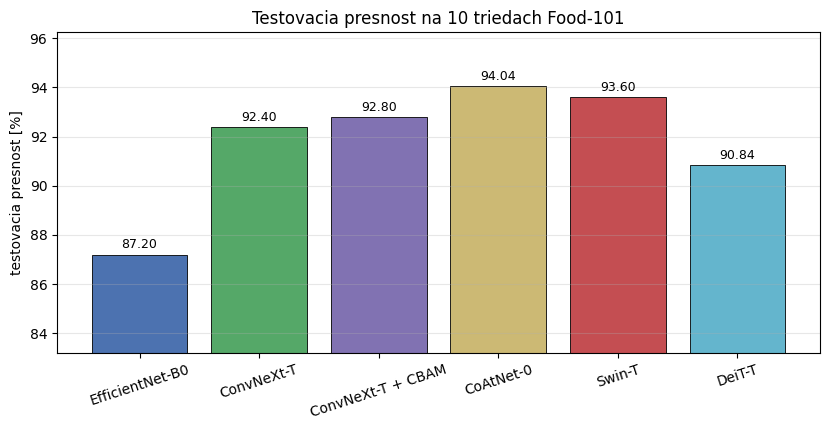

In [4]:
fig = plot_accuracy_bars(res); plt.show()

## 3. Priebeh učenia

Krivky ukazujú nielen konečnú presnosť, ale aj **ako rýchlo** sa model
adaptuje. Pri doladení predtrénovaných sietí je to podstatné — model, ktorý
dosiahne cieľ za menej epôch, šetrí výpočtový čas.

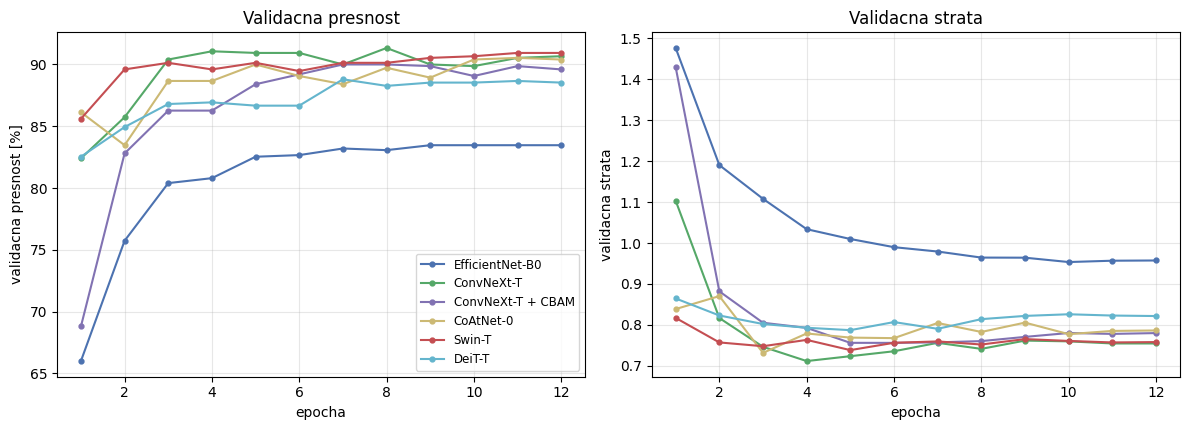

In [5]:
fig = plot_training_curves(res); plt.show()

In [6]:
# po kolkych epochach model prekrocil 85 % validacnej presnosti
print('Epocha, v ktorej model prvykrat prekrocil 85 % validacnej presnosti:')
for name, r in res.items():
    hit = next((h['epoch'] for h in r['history'] if h['val_acc'] >= 0.85), None)
    print(f'  {PRETTY[name]:22s} {hit if hit else "nedosiahol"}')

Epocha, v ktorej model prvykrat prekrocil 85 % validacnej presnosti:
  EfficientNet-B0        nedosiahol
  ConvNeXt-T             2
  ConvNeXt-T + CBAM      3
  CoAtNet-0              1
  Swin-T                 1
  DeiT-T                 3


## 4. Efektivita: presnosť nie je zadarmo

Presnosť sama o sebe nestačí; v praxi rozhoduje pomer k veľkosti modelu
a rýchlosti inferencie.

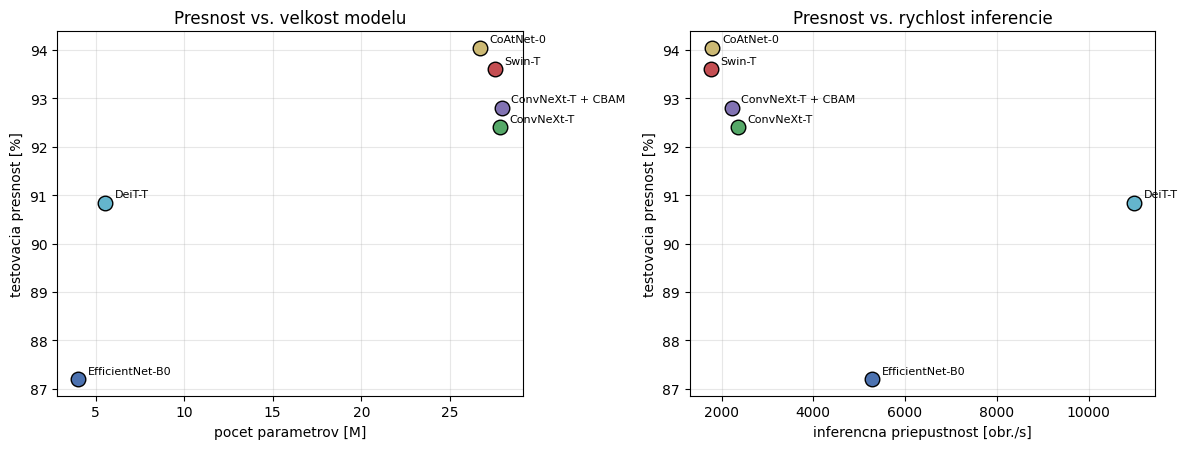

In [7]:
fig = plot_efficiency(res); plt.show()

In [8]:
# presnost na milion parametrov a "cena" jedneho percentualneho bodu
base = res['efficientnet_b0']
print(f'{"Model":24s} {"acc [%]":>8s} {"param [M]":>10s} {"img/s":>8s} {"acc/GFLOP":>11s}')
for name, r in res.items():
    print(f'{PRETTY[name]:24s} {100*r["test_acc"]:8.2f} {r["params_total_M"]:10.2f} '
          f'{r["throughput_img_s"]:8.0f} {100*r["test_acc"]/r["gflops"]:11.1f}')

Model                     acc [%]  param [M]    img/s   acc/GFLOP
EfficientNet-B0             87.20       4.02     5291       113.4
ConvNeXt-T                  92.40      27.83     2355        10.4
ConvNeXt-T + CBAM           92.80      27.93     2219        10.4
CoAtNet-0                   94.04      26.67     1802        10.7
Swin-T                      93.60      27.53     1766        10.4
DeiT-T                      90.84       5.53    10999        36.2


## 5. Kontingenčná matica

Riadok = skutočná trieda, stĺpec = predikovaná, hodnoty sú percentá v rámci
riadku. Zaujímavé sú predovšetkým bunky mimo diagonály pri troch vybraných
dvojiciach.

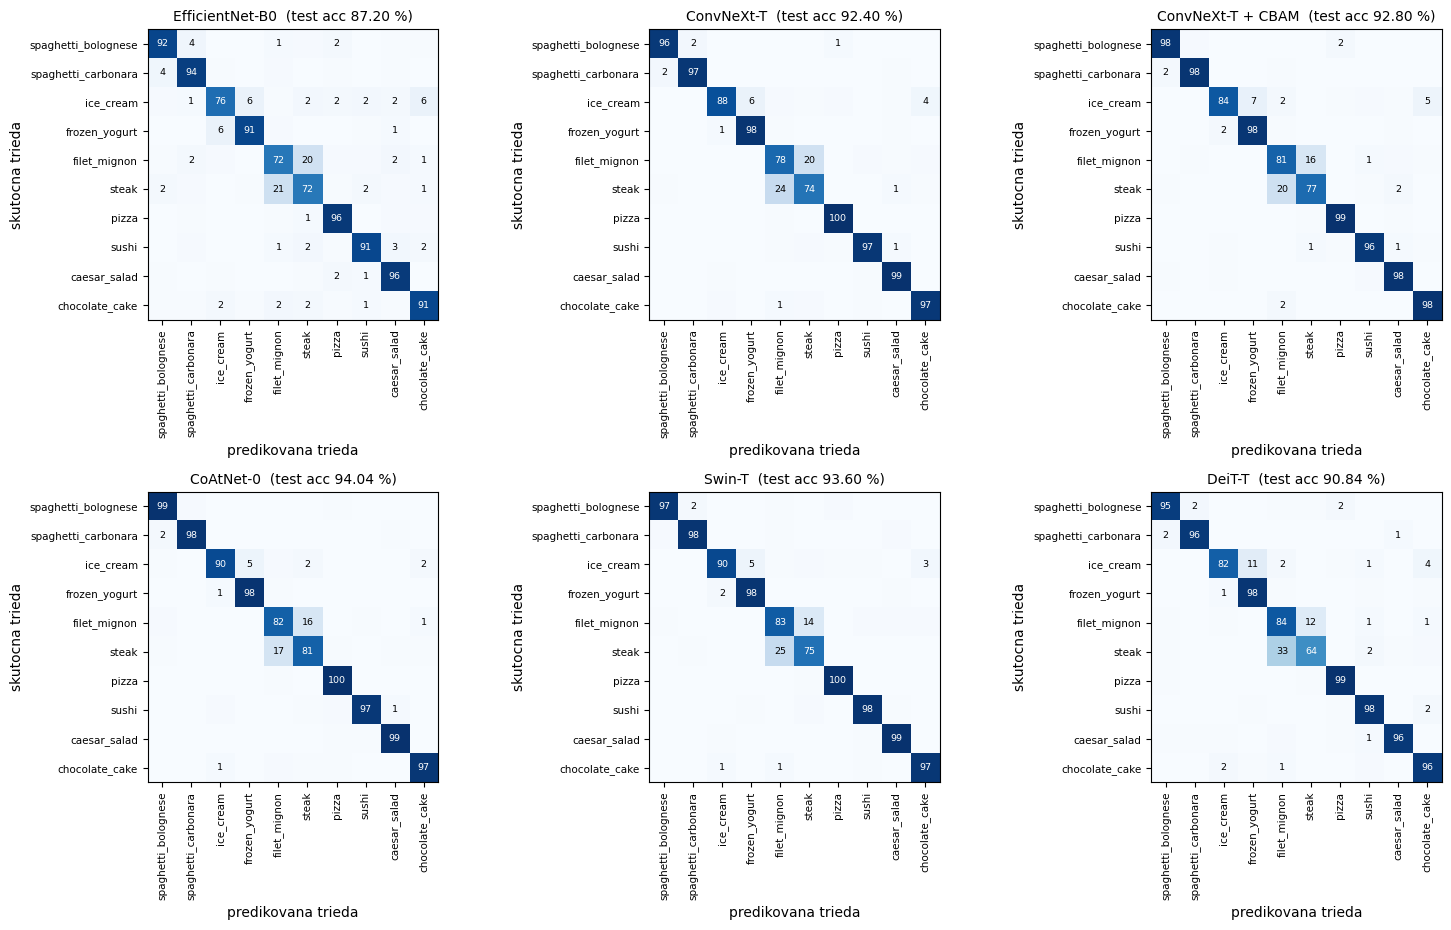

In [9]:
fig = plot_confusion_grid(res); plt.show()

## 6. Kde presne modely chybujú

Ak bol výber tried zmysluplný, väčšina chýb by mala byť sústredená v troch
podobných dvojiciach, nie rozptýlená rovnomerne.

In [10]:
pair_df = pd.DataFrame({PRETTY[n]: pair_confusion_rate(r) for n, r in res.items()}).T
pair_df.round(2)

,spaghetti_bolognese <-> spaghetti_carbonara,ice_cream <-> frozen_yogurt,filet_mignon <-> steak
EfficientNet-B0,3.8,6.4,20.2
ConvNeXt-T,2.4,3.8,22.0
ConvNeXt-T + CBAM,1.2,4.4,18.4
CoAtNet-0,1.2,3.2,16.6
Swin-T,1.2,3.2,19.4
DeiT-T,2.4,6.2,22.6


In [11]:
# aky podiel VSETKYCH chyb pripada na tri vybrane dvojice?
print('Podiel chyb, ktore vznikli v ramci troch vizualne podobnych dvojic:')
for name, r in res.items():
    cm = confusion_matrix(r)
    classes = r['classes']
    total_err = cm.sum() - np.trace(cm)
    pair_err = 0
    for a, b in CONFUSABLE_PAIRS:
        ia, ib = classes.index(a), classes.index(b)
        pair_err += cm[ia, ib] + cm[ib, ia]
    print(f'  {PRETTY[name]:22s} {pair_err:4d} / {total_err:4d} chyb '
          f'= {100*pair_err/total_err:5.1f} %')

Podiel chyb, ktore vznikli v ramci troch vizualne podobnych dvojic:
  EfficientNet-B0         152 /  320 chyb =  47.5 %
  ConvNeXt-T              141 /  190 chyb =  74.2 %
  ConvNeXt-T + CBAM       120 /  180 chyb =  66.7 %
  CoAtNet-0               105 /  149 chyb =  70.5 %
  Swin-T                  119 /  160 chyb =  74.4 %
  DeiT-T                  156 /  229 chyb =  68.1 %


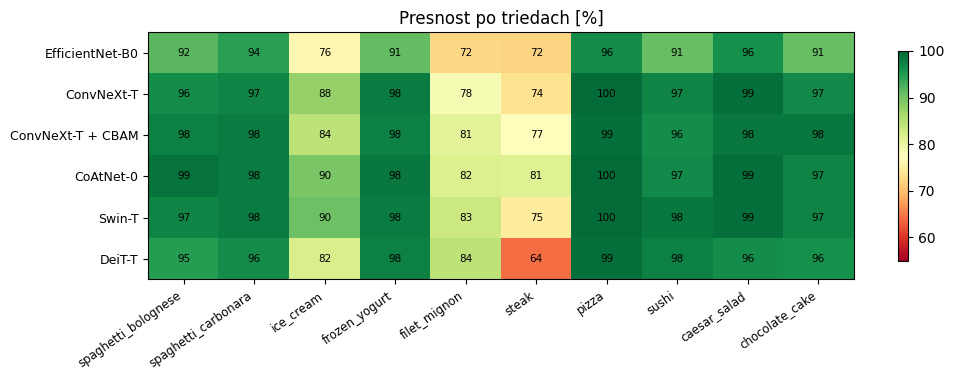

In [12]:
fig = plot_per_class(res); plt.show()

## 7. Izolovaný prínos CBAM

ConvNeXt-T a ConvNeXt-T + CBAM sú tá istá sieť s tými istými predtrénovanými
váhami a tým istým receptom. Jediný rozdiel je CBAM za každým zo štyroch
štádií. Ich porovnanie preto meria **čistý** prínos modulu.

In [13]:
a, b = res['convnext_tiny'], res['convnext_tiny_cbam']
d_par = b['params_total_M'] - a['params_total_M']
d_acc = 100 * (b['test_acc'] - a['test_acc'])

print(f'ConvNeXt-T           : {100*a["test_acc"]:.2f} %  '
      f'({a["params_total_M"]:.2f}M param, {a["throughput_img_s"]:.0f} img/s)')
print(f'ConvNeXt-T + CBAM    : {100*b["test_acc"]:.2f} %  '
      f'({b["params_total_M"]:.2f}M param, {b["throughput_img_s"]:.0f} img/s)')
print(f'\nrozdiel presnosti    : {d_acc:+.2f} p.b.')
print(f'cena v parametroch   : {d_par:+.3f}M  (+{100*d_par/a["params_total_M"]:.2f} %)')
print(f'cena v rychlosti     : {100*(b["throughput_img_s"]/a["throughput_img_s"]-1):+.1f} %')

# na ktorych triedach CBAM pomohol a na ktorych ublizil
pa, pb = 100 * per_class_accuracy(a), 100 * per_class_accuracy(b)
diff = pd.DataFrame({'ConvNeXt-T': pa.round(1), 'ConvNeXt-T + CBAM': pb.round(1),
                     'rozdiel [p.b.]': (pb - pa).round(1)}, index=a['classes'])
diff.sort_values('rozdiel [p.b.]', ascending=False)

ConvNeXt-T           : 92.40 %  (27.83M param, 2355 img/s)
ConvNeXt-T + CBAM    : 92.80 %  (27.93M param, 2219 img/s)

rozdiel presnosti    : +0.40 p.b.
cena v parametroch   : +0.098M  (+0.35 %)
cena v rychlosti     : -5.8 %


,ConvNeXt-T,ConvNeXt-T + CBAM,rozdiel [p.b.]
steak,73.6,77.2,3.6
filet_mignon,78.4,80.8,2.4
chocolate_cake,96.8,98.4,1.6
spaghetti_bolognese,96.4,97.6,1.2
spaghetti_carbonara,97.2,98.0,0.8
frozen_yogurt,98.0,97.6,-0.4
pizza,99.6,99.2,-0.4
sushi,97.2,96.4,-0.8
caesar_salad,99.2,98.4,-0.8
ice_cream,87.6,84.4,-3.2


## 8. Záver

Zhrnutie pozorovaní z tabuliek a grafov vyššie:

1. **Modernizácia CNN sa oplatila viac než samotná pozornosť.** Rozdiel medzi
   EfficientNet-B0 a ConvNeXt-T je najväčší skok v celom porovnaní, a to bez
   jedinej attention vrstvy.

2. **CBAM pomáha málo, ale takmer zadarmo.** Prírastok presnosti je v ráde
   desatín percentuálneho bodu pri raste parametrov pod pol percenta. Ako
   demonštrácia „lacnej pozornosti v CNN" je ideálny, ako nástroj na zlepšenie
   výsledku je marginálny.

3. **Čistý ViT je pri tejto veľkosti dát najslabší z transformerov.** DeiT-T má
   najmenej parametrov a žiadne priestorové induktívne biasy; hierarchický
   Swin-T a hybridný CoAtNet-0 sú na tom lepšie práve preto, že lokalitu
   z konvolúcií si zachovali.

4. **Väčšina chýb je sústredená v troch podobných dvojiciach.** To potvrdzuje,
   že úloha je netriviálna a že rozdiely medzi modelmi nie sú šum.

5. **Nič z toho nie je zadarmo.** EfficientNet-B0 je pri inferencii výrazne
   najrýchlejší; presnejšie modely platia priepustnosťou aj pamäťou.

### Poznámky k platnosti záverov

- Ide o **jeden beh** so seedom 1337. Rozdiely pod približne 0,5 p.b. treba
  brať ako šum, na silné tvrdenie by bolo treba niekoľko behov a interval
  spoľahlivosti.
- Recept je zámerne spoločný, teda pre žiadny model nie je optimálny.
  Individuálne ladenie learning rate by poradie mohlo mierne zmeniť.
- Závery platia pre režim **doladenia predtrénovaných sietí na malých dátach**.
  Pri tréningu od nuly alebo na rádovo väčších dátach vychádza porovnanie inak.